In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy
import os

## Helper Functions

In [ ]:
def clean_cols(df):
    #concat all columns that start with "AA03" into one column, and all columns that start with "Uncoated" into another column, then return the dataframe with only these 2 columns
    aa03_cols = df.filter(regex=r'^AA03',axis=1)
    uncoated_cols = df.filter(regex=r'^Un-1',axis=1)
    se02_cols = df.filter(regex=r'^SE02',axis=1)
    uncoated_cols_2 = df.filter(regex=r'^Un-2',axis=1)
    
    return pd.DataFrame({
        #"Time": df["Time"],
        "AA03": aa03_cols.mean(axis=1), #take the mean of all columns that start with AA03
        "Uncoated": uncoated_cols.mean(axis=1), #take the mean of all columns that start with Uncoated
        "Uncoated_2": uncoated_cols_2.mean(axis=1), #take the mean of all columns that start with Uncoated_2
        "SE02": se02_cols.mean(axis=1) #take the mean of all columns that start with SE02
    })

def remove_outliers_rolling(df, col, window, threshold):
    #2 step process, 1st is applying rolling median to remove outliers, then SMA for smoothing
    rolling_median = df[col].rolling(window, center=True, min_periods=1).median()
    diff = (df[col] - rolling_median).abs()

    removed = (diff>=threshold).sum()
    print(f"Removed {removed} outliers from column {col} using rolling median with window {window} and threshold {threshold}.")

    df[col] = df[col].where(diff < threshold, np.nan)
    return df

def smoothen(df, window_size):
    return df.rolling(window=window_size, min_periods=1).mean()

def detect_stable_segments(df, col, smooth_window=30, gradient_window=30,
                           stable_threshold=0.02, min_stable_length=120):
    df = df.copy()

    signal = df[col].rolling(window=smooth_window, min_periods=1).mean()
    gradient = signal.diff().abs().fillna(0)
    gradient_smooth = gradient.rolling(window=gradient_window, min_periods=1).mean()

    stable = gradient_smooth < stable_threshold

    segment_id = (stable != stable.shift()).cumsum()
    stable_segments = []

    marker_col = f"{col}_stable_marker"
    segment_col = f"{col}_stable_segment"

    df[marker_col] = np.nan
    df[segment_col] = False

    for _, segment in df[stable].groupby(segment_id[stable]):
        if len(segment) < min_stable_length:
            continue

        start_idx = segment.index[0]
        end_idx = segment.index[-1]

        stable_segments.append((start_idx, end_idx))

        df.loc[start_idx, marker_col] = df[col].max()
        df.loc[start_idx:end_idx, segment_col] = True

    print(f"Detected {len(stable_segments)} stable segments in column {col}")

    return df

In [41]:
folders = 'g:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/'
directory = 'test_0705_v2'
file = os.path.join(folders, directory, 'master_logs.csv')

print(file)
df = pd.read_csv(file)
print(df.head())
print(df.columns)

g:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/test_0705_v2\master_logs.csv
  Time_flex  AA03-1-1_flex  AA03-1-2_flex  AA03-1-3_flex  AA03-1-4_flex  \
0   31:48.1      57.477196      58.001980      54.874978      52.868766   
1   31:49.1      57.627045      58.164095      55.034391      52.992480   
2   31:50.1      57.764973      58.330343      55.185264      53.095970   
3   31:51.1      57.912880      58.493066      55.337333      53.176271   
4   31:52.1      58.046650      58.639307      55.457125      53.265018   

   AA03-2-1_flex  AA03-2-2_flex  AA03-2-3_flex  AA03-2-4_flex  SE02-1_flex  \
0      58.036019      56.439386      56.670591      53.001700    61.754712   
1      58.183786      56.568705      56.827963      53.119981    61.939505   
2      58.336334      56.694890      56.975966      53.228631    62.114577   
3      58.480660      56.833439      57.128166      53.358589    62.296127   
4      58.630326      56.947316      57.274996    

In [ ]:
df = clean_cols(df)
print(df)


            AA03  Uncoated  Uncoated_2        SE02
0      55.921327       NaN         NaN   54.346774
1      55.993066       NaN         NaN   54.418356
2      56.062560       NaN         NaN   54.488059
3      56.131932       NaN         NaN   54.557565
4      56.198808       NaN         NaN   54.625409
...          ...       ...         ...         ...
4129  167.459038       NaN         NaN  161.036306
4130  167.468247       NaN         NaN  161.042361
4131  167.477304       NaN         NaN  161.048846
4132  167.486345       NaN         NaN  161.055825
4133  167.495771       NaN         NaN  161.063134

[4134 rows x 4 columns]
Detected 5 stable segments in column AA03


In [46]:
df = detect_stable_segments(df, 'AA03', smooth_window=30, gradient_window=30, stable_threshold=0.02, min_stable_length=120)
df

Detected 5 stable segments in column AA03


,AA03,Uncoated,Uncoated_2,SE02,AA03_stable_marker,AA03_stable_segment
0,55.921327,NaN,NaN,54.346774,NaN,False
1,55.993066,NaN,NaN,54.418356,NaN,False
2,56.062560,NaN,NaN,54.488059,NaN,False
3,56.131932,NaN,NaN,54.557565,NaN,False
4,56.198808,NaN,NaN,54.625409,NaN,False
...,...,...,...,...,...,...
4129,167.459038,NaN,NaN,161.036306,NaN,False
4130,167.468247,NaN,NaN,161.042361,NaN,False
4131,167.477304,NaN,NaN,161.048846,NaN,False
4132,167.486345,NaN,NaN,161.055825,NaN,False


Removed 0 outliers from column AA03 using rolling median with window 30 and threshold 1.
Removed 0 outliers from column Uncoated using rolling median with window 30 and threshold 1.
Removed 0 outliers from column Uncoated_2 using rolling median with window 30 and threshold 1.
Removed 0 outliers from column SE02 using rolling median with window 30 and threshold 1.


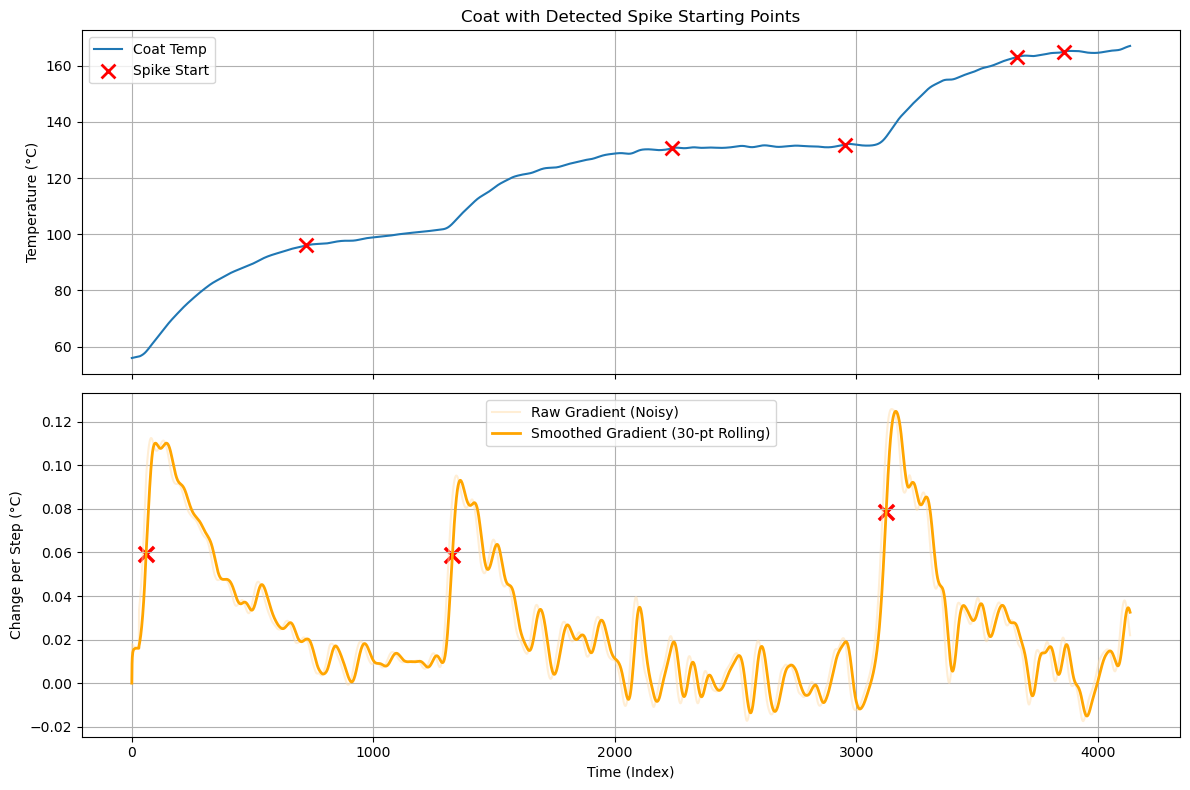

In [48]:
from scipy.signal import find_peaks

#coat = df['AA03_temp']

cols = ["AA03", "Uncoated", "Uncoated_2", "SE02"]
for col in cols:    
    df = remove_outliers_rolling(df, col, window=30, threshold=1)
df[cols] = smoothen(df[cols], window_size=30)

index = df.index
coat_aa03 = df['AA03']
coat_se02 = df['SE02']
coat_uncoated = df['Uncoated']
raw_gradient = coat_aa03.diff().fillna(0)  # Calculate the gradient and fill NaN values with 0
coat_gradient_smooth = raw_gradient.rolling(window=30, min_periods=1).mean()  # Smooth the gradient with a rolling mean

#now detect spikes in coat using scipy.signal.find_peaks
# peaks, _ = find_peaks(
#     coat_gradient_smooth, 
#     height=0.08, #y-value (temp) threshold
#     distance=300, #big distance to avoid multiple peaks
#     prominence=0.05)  # How much peak stands out from the baseline

# window_offset = 50
# adjusted_peaks = [max(0, p-window_offset) for p in peaks]
#minus 15 to get the start of the spike, but ensure we don't go below index 0


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top Plot: Raw Temperature with detected start times
ax1.plot(index, coat_aa03, label='Coat Temp', color='#1f77b4')
# ax1.plot(index, coat_se02, label='SE02 Temp', color='#ff7f0e')
# ax1.plot(index, coat_uncoated, label='Uncoated Temp', color='#9d9d9c')
ax1.scatter(df[df['AA03_stable_marker'].notnull()].index, coat_aa03[df['AA03_stable_marker'].notnull()], color='red', marker='x', s=100, lw=2, label='Spike Start', zorder=5)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Coat with Detected Spike Starting Points')
ax1.legend()
ax1.grid(True)

# Bottom Plot: The Gradient (Rate of Change) showing the actual peaks
ax2.plot(index, raw_gradient, label='Raw Gradient (Noisy)', color='navajowhite', alpha=0.5)
ax2.plot(index, coat_gradient_smooth, label='Smoothed Gradient (30-pt Rolling)', color='orange', lw=2)
ax2.scatter(index[peaks], coat_gradient_smooth[peaks], color='red', marker='x', s=120, lw=2.5)
ax2.set_xlabel('Time (Index)')
ax2.set_ylabel('Change per Step (°C)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [1]:
print(5//2)
print(5%2)

2
1
